# Stage 01 Relative-Distance Training Notebook

这份 notebook 只做一件事：
- 输入 `3` 个参考麦之间的相对距离和 `3` 个 TDOA
- 输出噪声源到 `3` 个参考麦的距离 `[r1, r2, r3]`
- 评估阶段再用三圆方程的线性化最小二乘反解回 `(x, y)`

它默认复用当前稳定几何数据集，不重建 H5。

In [1]:
from pathlib import Path
import json
import sys
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
try:
    import torch
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook needs an interpreter/kernel with torch installed. Please switch to your myenv Python before running it."
    ) from exc
from IPython.display import Image, display

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / '.gitignore').exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'python_impl').exists():
    raise RuntimeError(f'Failed to locate repo root from {NOTEBOOK_DIR}')

STAGE01_DIR = REPO_ROOT / 'python_impl' / 'experiments' / 'hypothesis_validation' / '01_source_localization_anechoic_2d'
SRC_DIR = STAGE01_DIR / 'src'
for path in (REPO_ROOT, SRC_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from relative_distance_notebook_utils import (
    build_relative_distance_bundle,
    random_consistency_check,
    reconstruct_xy_from_radii,
    train_relative_distance_model,
    load_summary,
)

print(f'Notebook dir: {NOTEBOOK_DIR}')
print(f'Repo root: {REPO_ROOT}')
print(f'Stage01 dir: {STAGE01_DIR}')

Notebook dir: z:\anc\distributed_anc_sim_py\python_impl\experiments\hypothesis_validation\01_source_localization_anechoic_2d\notebooks
Repo root: z:\anc\distributed_anc_sim_py
Stage01 dir: z:\anc\distributed_anc_sim_py\python_impl\experiments\hypothesis_validation\01_source_localization_anechoic_2d


In [2]:
# Parameters
USE_TRUE_TDOA = True
# Default to the stable_v3 30k dataset with near-ref, obtuse, and small-angle source-region constraints.
H5_PATH = STAGE01_DIR / 'data' / 'source_localization_anechoic_2d_l2_stable_v3_30k.h5'
ALPHA = 1.0
BETA = 1.0
LR = 1.0e-3
BATCH_SIZE = 128
EPOCHS = 200
SEED = 7
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RUN_NAME = 'relative_distance_l2_stable_v3_30k_true_tdoa' if USE_TRUE_TDOA else 'relative_distance_l2_stable_v3_30k_gcc_tdoa'
RESULT_DIR = STAGE01_DIR / 'results' / RUN_NAME

print('H5_PATH =', H5_PATH)
print('RESULT_DIR =', RESULT_DIR)
print('DEVICE =', DEVICE)

H5_PATH = z:\anc\distributed_anc_sim_py\python_impl\experiments\hypothesis_validation\01_source_localization_anechoic_2d\data\source_localization_anechoic_2d_l2_stable_v3_30k.h5
RESULT_DIR = z:\anc\distributed_anc_sim_py\python_impl\experiments\hypothesis_validation\01_source_localization_anechoic_2d\results\relative_distance_l2_stable_v3_30k_true_tdoa
DEVICE = cuda


In [3]:
bundle = build_relative_distance_bundle(H5_PATH, use_true_tdoa=USE_TRUE_TDOA)
print('Split sizes:')
pprint(bundle.split_sizes)
print('Removed train samples due to geom holdout overlap =', bundle.train_overlap_removed)
print('near_ref_inside_threshold_m =', bundle.near_ref_inside_threshold_m)
print('source_region_rule_version =', bundle.source_region_rule_version)

consistency = random_consistency_check(bundle, num_samples=32, seed=SEED)
print('\nRandom consistency check (r_i - r_j vs c * tdoa_ij):')
pprint(consistency)

sample_idx = 0
xy_from_true_r = reconstruct_xy_from_radii(bundle.ref_positions[[sample_idx]], bundle.target_r[[sample_idx]])[0]
print('\nTrue-radius reconstruction sanity check:')
print('true xy     =', bundle.target_xy[sample_idx].tolist())
print('recovered xy=', xy_from_true_r.tolist())
print('reconstruction error (m)=', float(np.linalg.norm(xy_from_true_r - bundle.target_xy[sample_idx])))

Split sizes:
{'geom_test': 6009,
 'geom_val': 2399,
 'iid_test': 4500,
 'iid_val': 4500,
 'train': 15105}
Removed train samples due to geom holdout overlap = 5895
near_ref_inside_threshold_m = 0.5
source_region_rule_version = stage01_stable_v3

Random consistency check (r_i - r_j vs c * tdoa_ij):
{'max_abs_err_m': 2.384185791015625e-07,
 'mean_abs_err_m': 7.914301392020207e-08,
 'num_samples': 32}

True-radius reconstruction sanity check:
true xy     = [1.8065176010131836, 2.137467384338379]
recovered xy= [1.8065176010131836, 2.137467384338379]
reconstruction error (m)= 0.0


## Train

训练时网络只看 `6` 维输入：
`[d12, d23, d13, tdoa12, tdoa23, tdoa13]`。

输出是 `[r1, r2, r3]`，损失是：
- 距离重建损失 `MSE(r_pred, r_true)`
- 物理几何一致性损失 `MSE((r_i-r_j), c*TDOA_ij)`

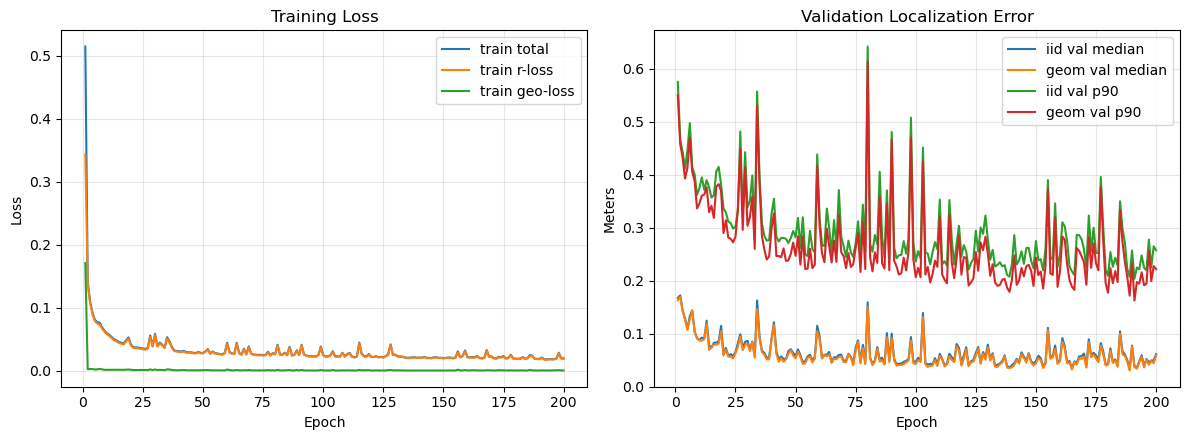

Training finished. Summary written to:
z:\anc\distributed_anc_sim_py\python_impl\experiments\hypothesis_validation\01_source_localization_anechoic_2d\results\relative_distance_l2_stable_v3_30k_true_tdoa\summary.json


In [4]:
summary = train_relative_distance_model(
    bundle=bundle,
    result_dir=RESULT_DIR,
    alpha=ALPHA,
    beta=BETA,
    lr=LR,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    seed=SEED,
    device=DEVICE,
    live_plot=True,
)
print('Training finished. Summary written to:')
print(RESULT_DIR / 'summary.json')

In [5]:
summary = load_summary(RESULT_DIR)
print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "h5_path": "z:\\anc\\distributed_anc_sim_py\\python_impl\\experiments\\hypothesis_validation\\01_source_localization_anechoic_2d\\data\\source_localization_anechoic_2d_l2_stable_v3_30k.h5",
  "use_true_tdoa": true,
  "fs": 16000,
  "c": 343.0,
  "room_size": [
    4.0,
    4.0
  ],
  "geometry_filter_mode": "stable",
  "min_triangle_area": 0.25,
  "max_jacobian_condition": 30.0,
  "max_triangle_angle_deg": 120.0,
  "near_ref_inside_threshold_m": 0.5,
  "source_region_rule_version": "stage01_stable_v3",
  "alpha": 1.0,
  "beta": 1.0,
  "lr": 0.001,
  "batch_size": 128,
  "epochs": 200,
  "seed": 7,
  "split_sizes": {
    "train": 15105,
    "iid_val": 4500,
    "iid_test": 4500,
    "geom_val": 2399,
    "geom_test": 6009
  },
  "train_overlap_removed": 5895,
  "best_epoch": 191,
  "best_selector": [
    0.16249987793881146,
    0.036868085056289815,
    0.20362347363847938,
    0.038457575481330164
  ],
  "checkpoint_path": "z:\\anc\\distributed_anc_sim_py\\python_impl\\experiments

## Saved Figures

下面直接读取训练时落盘的图：loss 曲线、`iid_test`/`geom_test` 散点图，以及成功/失败样本图。


loss_curves.png


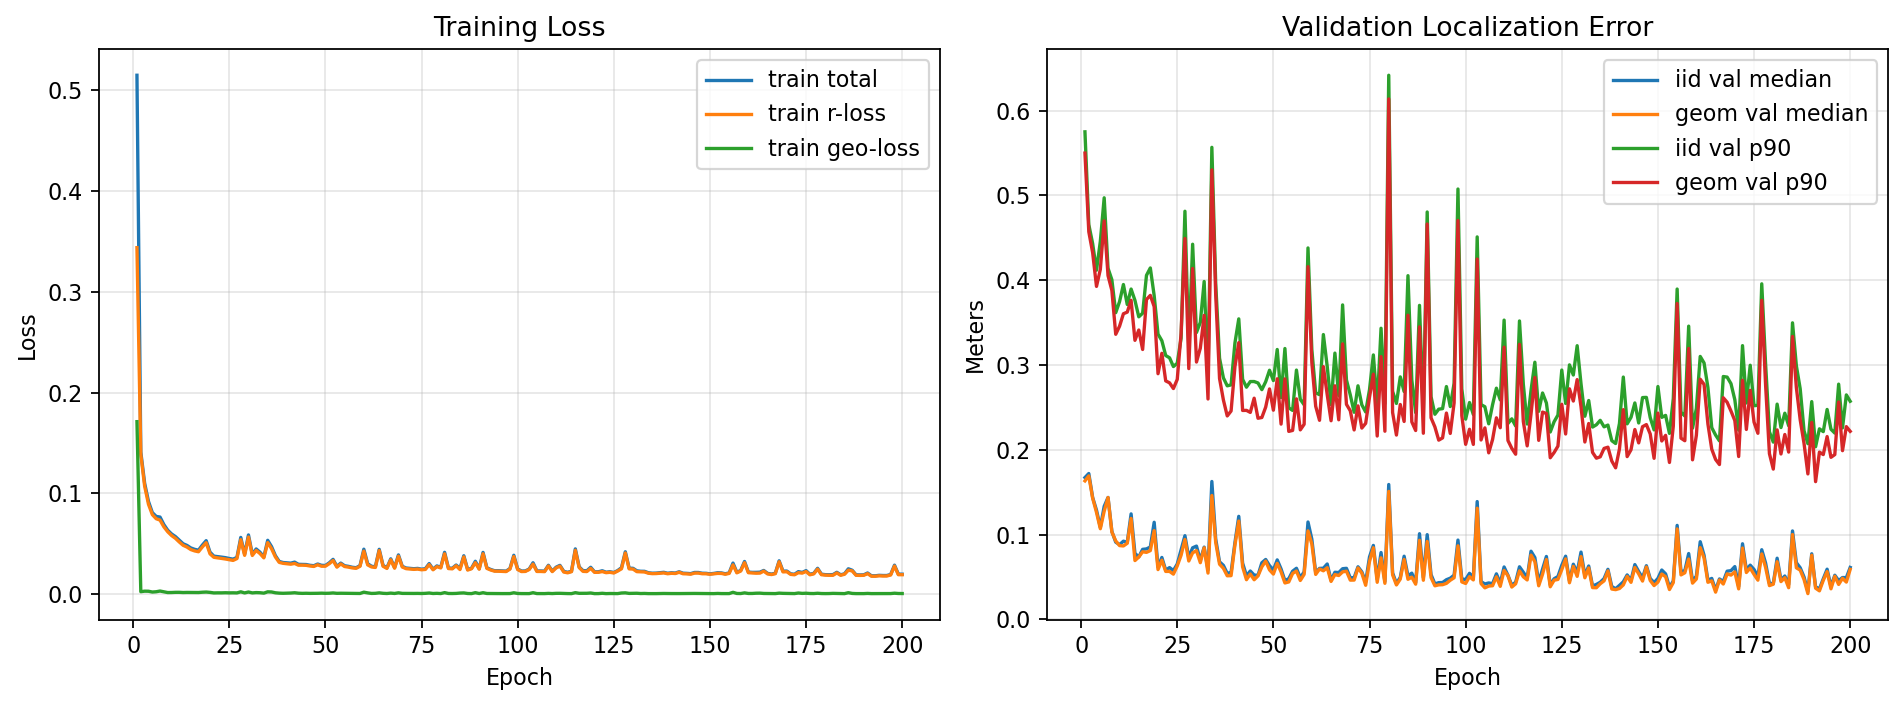


scatter_iid_test.png


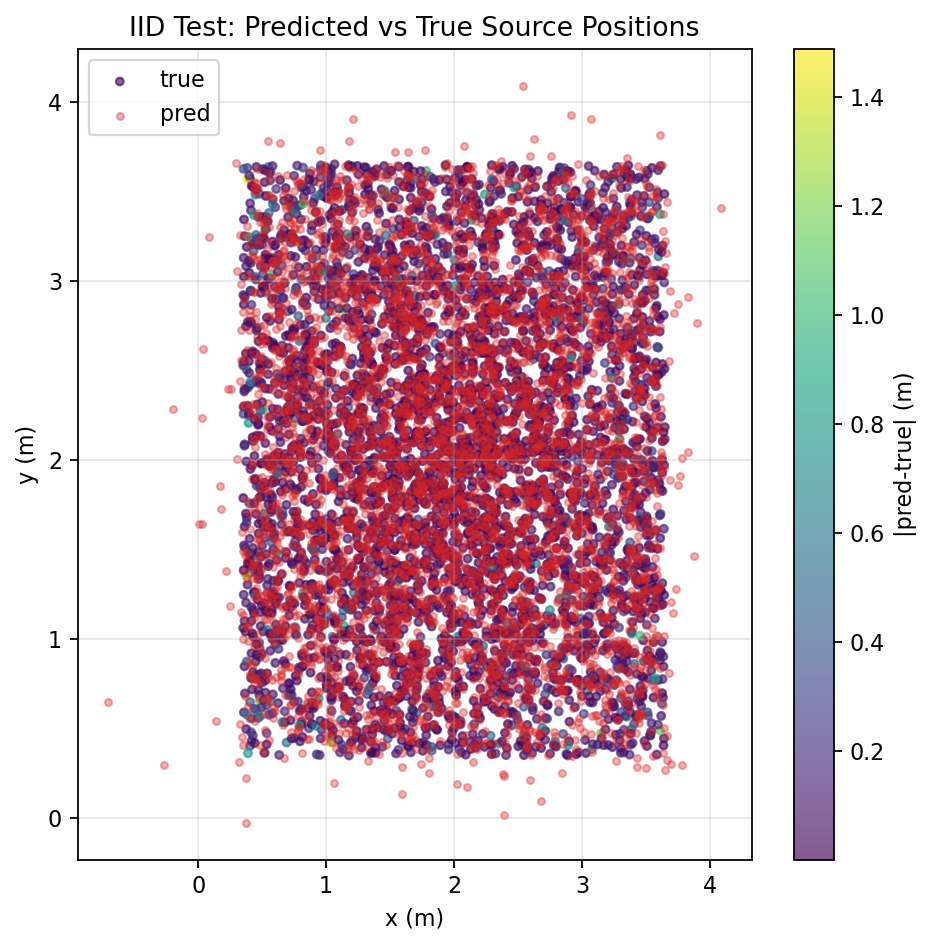


scatter_geom_test.png


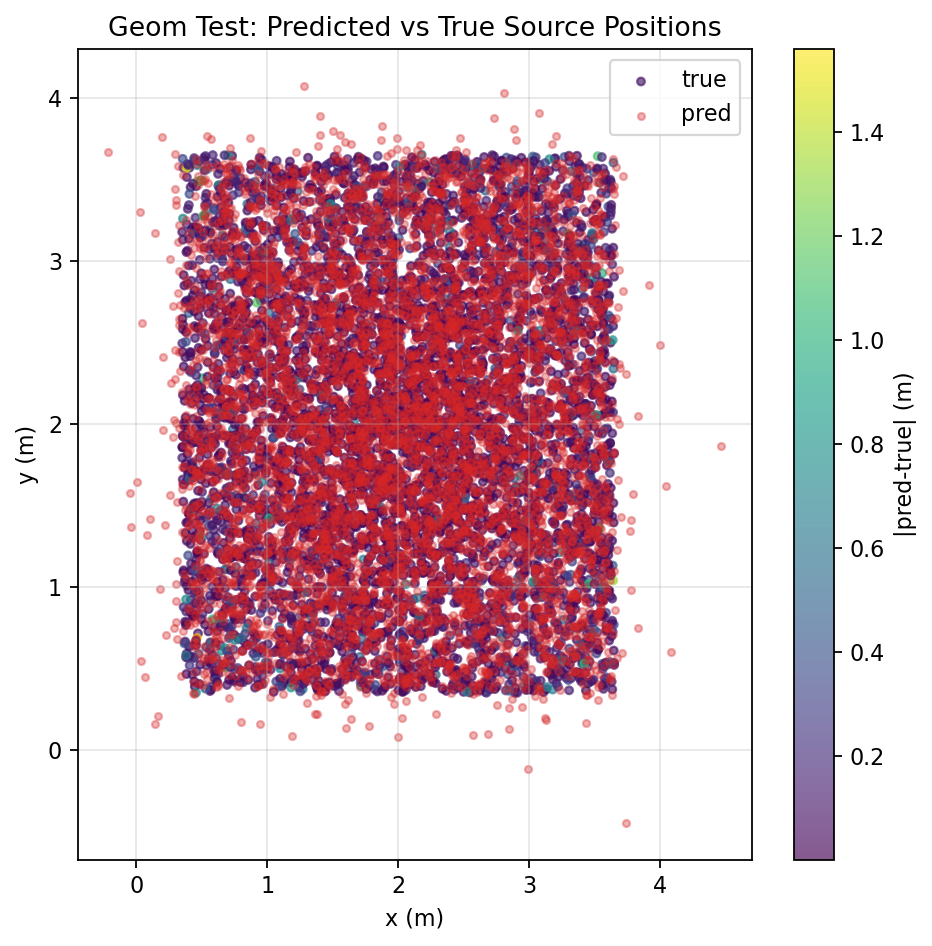


samples_iid_test.png


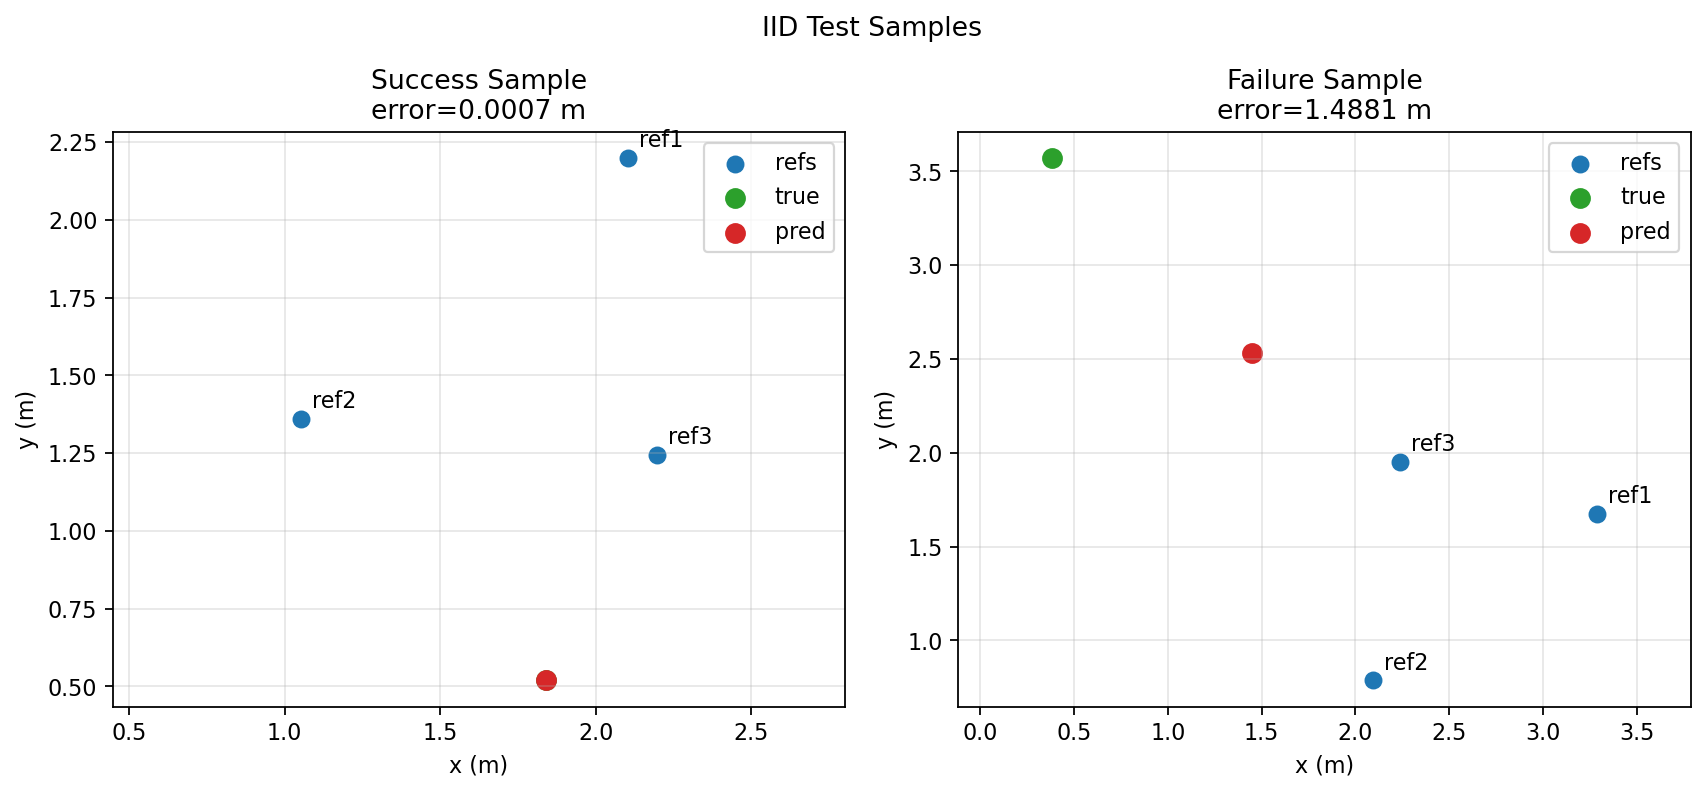


samples_geom_test.png


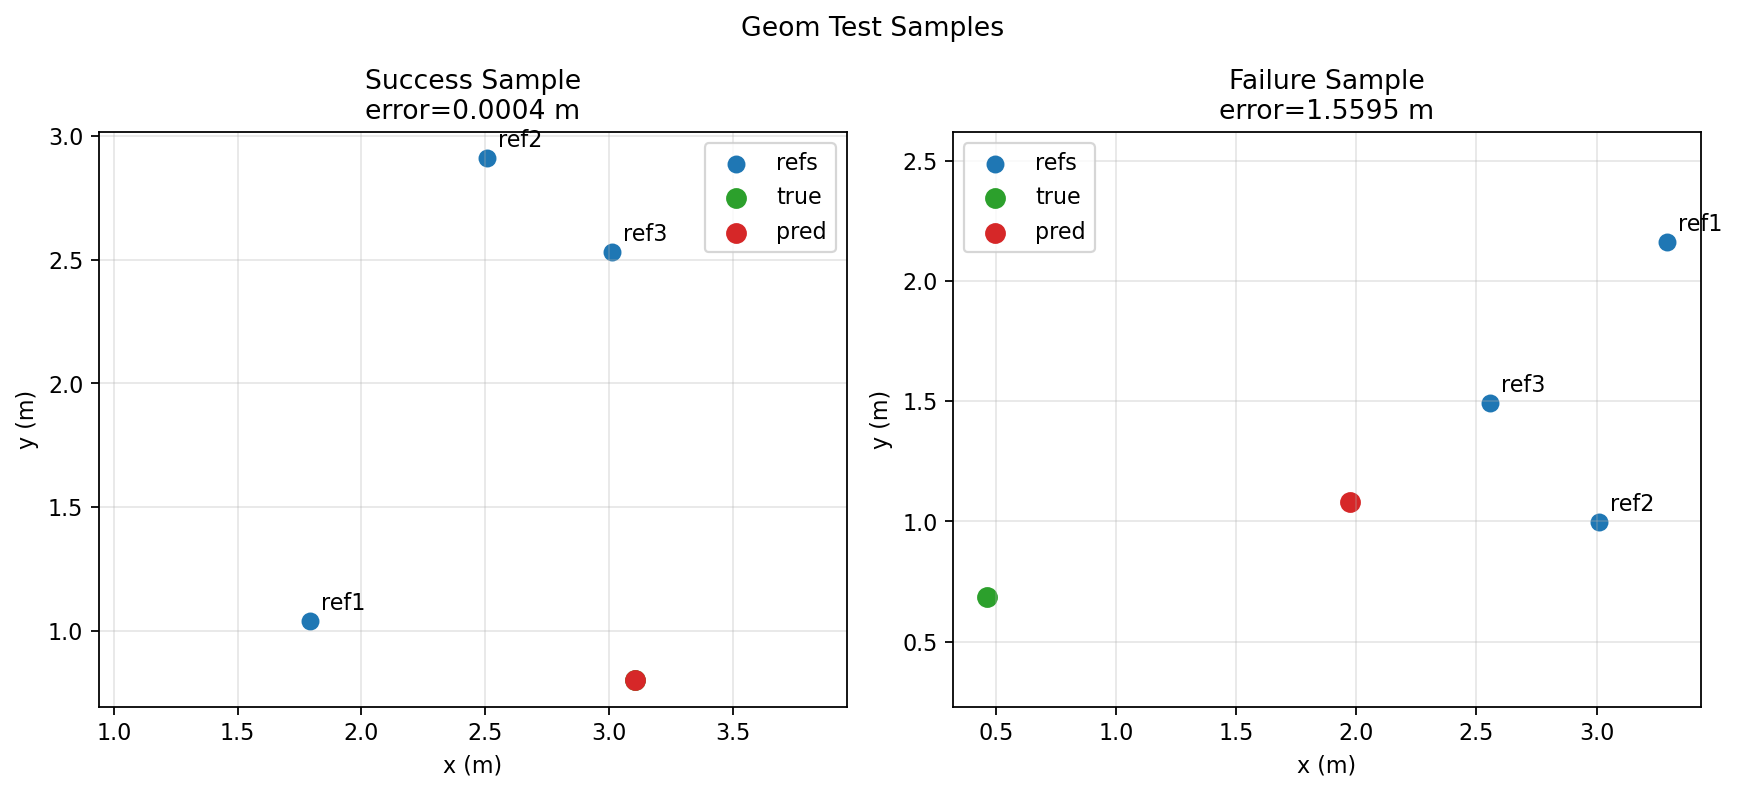

In [6]:
for name in [
    'loss_curves.png',
    'scatter_iid_test.png',
    'scatter_geom_test.png',
    'samples_iid_test.png',
    'samples_geom_test.png',
]:
    path = RESULT_DIR / name
    print(f'\n{name}')
    display(Image(filename=str(path)))

## Optional Next Step

如果你想改成用 `gcc_phat` 估计的 TDOA 而不是真值 TDOA，只需要把参数区中的：

`USE_TRUE_TDOA = False`

其它网络接口和训练/评估流程都不用改。